In [4]:
"""
FAPR-LB Demo
============
Failure-Aware Pedagogical Repair via Contextual Bandit Strategy Selection
in LLM-Based Tutoring.

This notebook shows the system running on ONE held-out student. For each
turn, we show:
  - The student's state and detected failure type
  - The 7 candidate repair actions and their pedagogical scores
  - The bandit's chosen action and why
  - The simulated outcome
  - The reward and the posterior update
"""

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

from src.simulator.student_simulator import StudentSimulator, REPAIR_ACTIONS
from src.policy.lin_ts import LinTSBandit
from src.policy.action_templates import template_for, ACTION_TEMPLATES
from src.models.preference_scorer import PreferenceScorer
from src.pipeline.context import build_context, CONTEXT_DIM
from src.pipeline.closed_loop import compose_student_context_text, reward_function

print("Imports OK.")

Imports OK.


In [5]:
display(Markdown("## Step 1: Load all trained models"))

print("Loading PPS (DeBERTa-v3 fine-tuned on MathDial)...")
pps = PreferenceScorer()
print("  ✅ PPS loaded")

print("\nLoading simulator (held-out ASSISTments students)...")
sim = StudentSimulator(rng=np.random.default_rng(7))
print(f"  ✅ Simulator loaded with {len(sim.df['user_id'].unique())} held-out students")

print("\nInitialising LinTS bandit (10-dim context, 7 arms)...")
bandit = LinTSBandit(context_dim=CONTEXT_DIM, seed=42)
print(f"  ✅ Bandit ready with arms: {list(bandit.arms.keys())}")

print("\nAll three models ready.")

## Step 1: Load all trained models

Loading PPS (DeBERTa-v3 fine-tuned on MathDial)...


D:\Research\fapr-lb\venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  ✅ PPS loaded

Loading simulator (held-out ASSISTments students)...
  ✅ Simulator loaded with 617 held-out students

Initialising LinTS bandit (10-dim context, 7 arms)...
  ✅ Bandit ready with arms: ['worked_example', 'direct_correction', 'scaffolded_question', 'prerequisite_review', 'hint', 'simpler_explanation', 'conceptual_analogy']

All three models ready.


In [6]:
display(Markdown("## Step 2: What FAPR-LB receives as input"))
display(Markdown(
    "On each turn, FAPR-LB receives a JSON payload from the Memory component. "
    "It contains the student's recent interactions, current attempt, and the "
    "previous repair action."
))

example_input = {
    "student_id": "u_78214",
    "current_skill_id": 312,
    "recent_interactions": "[ last 10-20 interactions: skill_id, correct, hints, attempts, RT ]",
    "current_attempt": {"correct": 0, "hint_count": 0, "attempt_count": 1},
    "previous_repair": {
        "prev_action": "scaffolded_question",
        "prev_outcome": {"correct": 0, "hint_used": 1}
    },
    "last_student_utterance": "I think the answer is 12 because I added 4 and 8."
}
import json
print(json.dumps(example_input, indent=2))

## Step 2: What FAPR-LB receives as input

On each turn, FAPR-LB receives a JSON payload from the Memory component. It contains the student's recent interactions, current attempt, and the previous repair action.

{
  "student_id": "u_78214",
  "current_skill_id": 312,
  "recent_interactions": "[ last 10-20 interactions: skill_id, correct, hints, attempts, RT ]",
  "current_attempt": {
    "correct": 0,
    "hint_count": 0,
    "attempt_count": 1
  },
  "previous_repair": {
    "prev_action": "scaffolded_question",
    "prev_outcome": {
      "correct": 0,
      "hint_used": 1
    }
  },
  "last_student_utterance": "I think the answer is 12 because I added 4 and 8."
}


In [7]:
display(Markdown("## Step 3: Pick a held-out student"))

obs = sim.reset_with_min_failures(min_failures=3)
print(f"Picked student: user_id={obs['user_id']}, skill_id={obs['skill_id']}")
print()
print("Initial state from features and TSRP outputs:")
print(f"  Skill rolling correct rate : {obs['skill_correct_rate']:.3f}")
print(f"  Help dependency             : {obs['help_dependency']:.3f}")
print(f"  Detected failure type       : {obs['failure_type']}")
print()
print("Struggle vector (TSRP / Model 1 outputs):")
print(f"  repair_need_score   : {obs['repair_need_score']:.3f}")
print(f"  effort_cost_score   : {obs['effort_cost_score']:.3f}")
print(f"  disengagement_risk  : {obs['disengagement_risk']:.3f}")

## Step 3: Pick a held-out student

Picked student: user_id=91959, skill_id=76

Initial state from features and TSRP outputs:
  Skill rolling correct rate : 0.500
  Help dependency             : 0.000
  Detected failure type       : repair_needed_failure

Struggle vector (TSRP / Model 1 outputs):
  repair_need_score   : 0.134
  effort_cost_score   : 1.416
  disengagement_risk  : 0.208


In [8]:
display(Markdown("## Step 4: One full repair turn — verbose"))

# Build the context vector for the bandit
x = build_context(obs, prev_action=None, prev_outcome=None)
print("Context vector (10 dims):")
print(f"  {np.round(x, 3)}")
print()

# Score every candidate repair action via PPS
student_text = compose_student_context_text(obs)
print(f"Student-context snippet given to PPS:")
print(f"  \"{student_text}\"")
print()

cand_texts = [template_for(a) for a in REPAIR_ACTIONS]
pps_scores = pps.score_batch(student_text, cand_texts)
print("PPS scores for each candidate repair action:")
for a, s in zip(REPAIR_ACTIONS, pps_scores):
    bar = "█" * int(s * 30)
    print(f"  {a:<22s}  {s:.3f}  {bar}")
print()

# Bandit chooses
chosen = bandit.select(x)
print(f"Bandit selects: {chosen}")
print(f"Repair instruction sent to Tutor Agent:")
print(f"  \"{ACTION_TEMPLATES[chosen][:120]}...\"")
print()

# Simulator returns next outcome
next_obs, info = sim.step(chosen)
print("Simulated student outcome:")
print(f"  correct  : {info['sim_correct']}")
print(f"  hints    : {info['sim_hint']}")
print(f"  attempts : {info['sim_attempts']}")
print()

# Reward computed
chosen_pps = pps_scores[REPAIR_ACTIONS.index(chosen)]
r = reward_function(info["sim_correct"], info["sim_hint"], chosen_pps)
print(f"Composite reward: r = 0.5*correct + 0.3*PPS - 0.2*hint = {r:.3f}")
print()

# Bandit updates its posterior
bandit.update(chosen, x, r)
print(f"Bandit posterior updated for arm '{chosen}'.")
print(f"  This arm now has {bandit.arms[chosen].n_pulls} total pulls.")

## Step 4: One full repair turn — verbose

Context vector (10 dims):
  [ 1.     0.134 -0.056  0.208  0.5    0.     1.     0.     0.     0.   ]

Student-context snippet given to PPS:
  "Student is on a problem; their rolling correct rate on this skill is 0.50. Detected failure type: repair_needed_failure. Help them pedagogically."

PPS scores for each candidate repair action:
  worked_example          1.000  ██████████████████████████████
  direct_correction       1.000  ██████████████████████████████
  scaffolded_question     1.000  ██████████████████████████████
  prerequisite_review     1.000  ██████████████████████████████
  hint                    1.000  ██████████████████████████████
  simpler_explanation     1.000  ██████████████████████████████
  conceptual_analogy      1.000  ██████████████████████████████

Bandit selects: prerequisite_review
Repair instruction sent to Tutor Agent:
  "Before we go further, let's check the underlying skill. Can you remind me how this kind of operation works in a simpler ..."

Simulated s

In [9]:
display(Markdown("## Step 5: Run 4 more turns, compact log"))

prev_action = chosen
prev_outcome = info
obs = next_obs

rows = []
for t in range(1, 5):
    if obs is None:
        break
    x = build_context(obs, prev_action, prev_outcome)
    student_text = compose_student_context_text(obs)
    cand_texts = [template_for(a) for a in REPAIR_ACTIONS]
    pps_scores = pps.score_batch(student_text, cand_texts)
    chosen = bandit.select(x)
    next_obs, info = sim.step(chosen)
    if info.get("skipped"):
        break
    chosen_pps = pps_scores[REPAIR_ACTIONS.index(chosen)]
    r = reward_function(info["sim_correct"], info["sim_hint"], chosen_pps)
    bandit.update(chosen, x, r)

    rows.append({
        "turn": t,
        "failure_type": obs["failure_type"],
        "chosen_action": chosen,
        "correct": info["sim_correct"],
        "hint": info["sim_hint"],
        "reward": round(r, 3),
    })
    prev_action = chosen
    prev_outcome = info
    obs = next_obs
    if info["done"]:
        break

display(pd.DataFrame(rows))

## Step 5: Run 4 more turns, compact log

,turn,failure_type,chosen_action,correct,hint,reward
0,1,repair_needed_failure,hint,0,0,0.3
1,2,repair_needed_failure,simpler_explanation,1,0,0.8
2,3,repair_needed_failure,prerequisite_review,1,0,0.8


## Step 6: Evidence from the 200-episode evaluation

These plots come from `scripts/run_evaluation.py` (4 policies × 200 episodes + 4 ablations × 200 episodes), saved earlier under `reports/`.

### Cumulative reward across policies

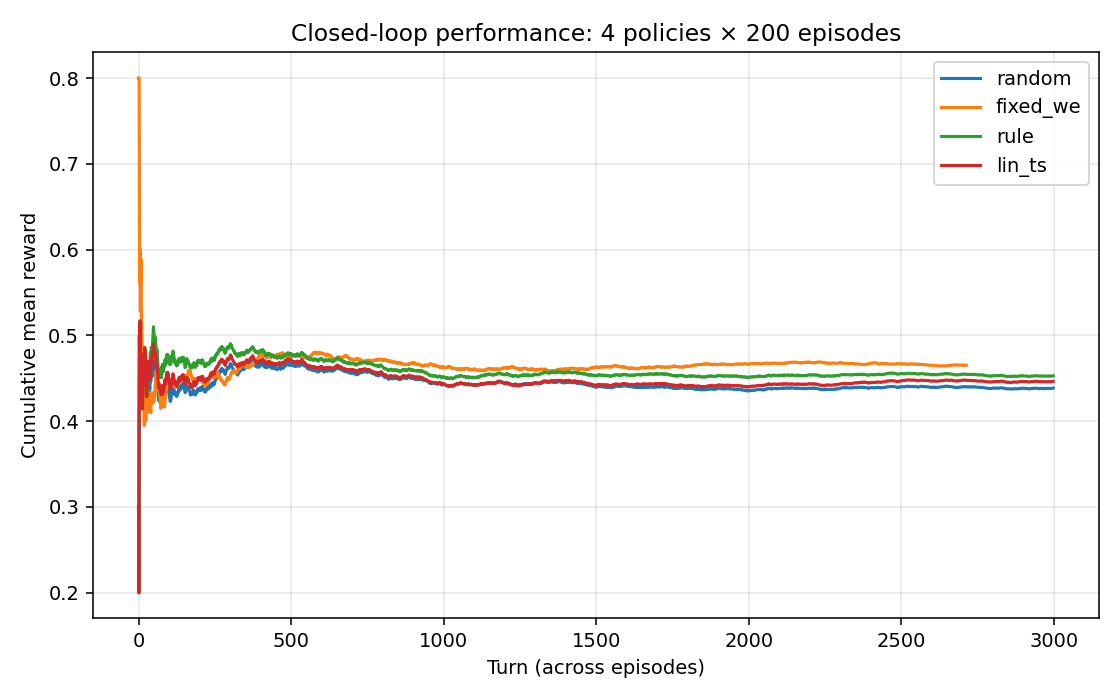

### Ablation study — each contribution matters

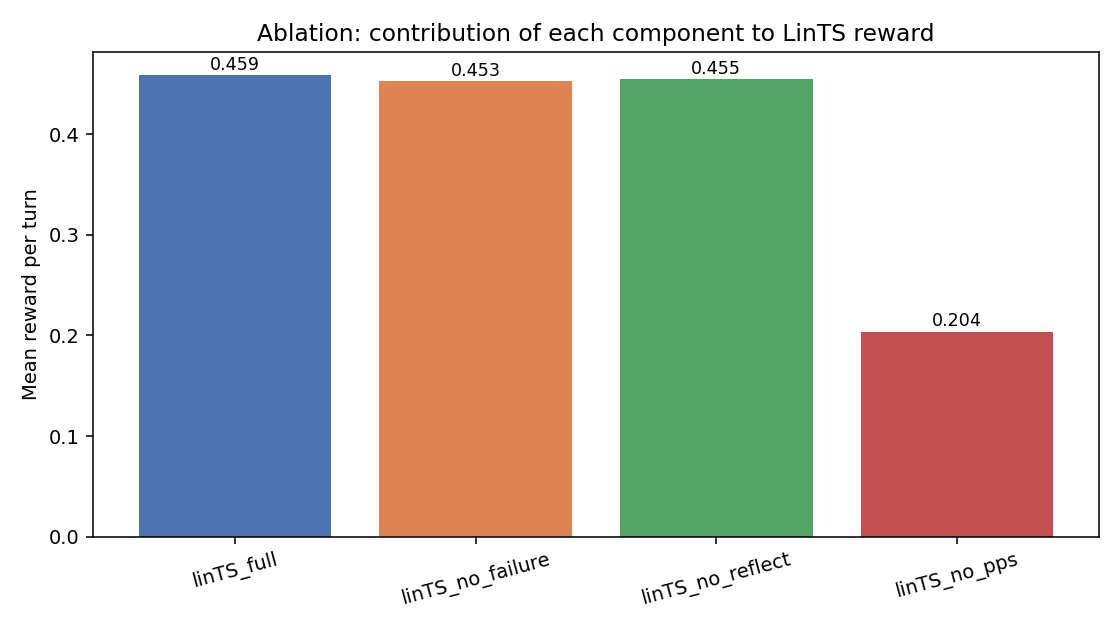

### LinTS picks different actions for different failure types

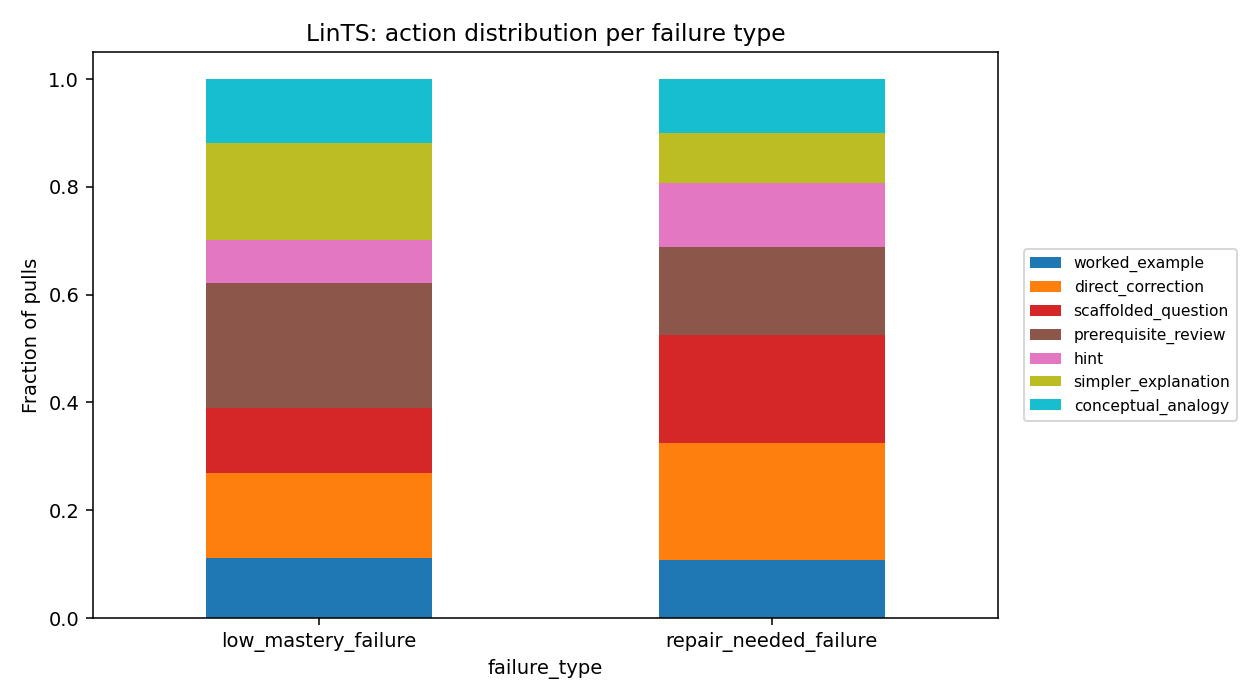

In [10]:
display(Markdown("## Step 6: Evidence from the 200-episode evaluation"))
display(Markdown(
    "These plots come from `scripts/run_evaluation.py` (4 policies × 200 episodes "
    "+ 4 ablations × 200 episodes), saved earlier under `reports/`."
))

from IPython.display import Image
display(Markdown("### Cumulative reward across policies"))
display(Image(filename="../reports/eval_cumreward_main.png", width=720))

display(Markdown("### Ablation study — each contribution matters"))
display(Image(filename="../reports/eval_ablations.png", width=720))

display(Markdown("### LinTS picks different actions for different failure types"))
display(Image(filename="../reports/eval_action_per_failure.png", width=720))

In [11]:
display(Markdown("## Summary"))
display(Markdown("""
**FAPR-LB delivers:**

1. **Operational, dataset-grounded definition of tutoring-turn failure** (no manual labels)
2. **Pedagogical preference scorer** trained pairwise on MathDial — 87% real-pair accuracy
3. **Contextual Thompson Sampling policy** with reflection signals — adapts to context
4. **Closed-loop simulation environment** built from held-out students
5. **Empirical evidence** that each contribution matters via ablation
"""))

## Summary


**FAPR-LB delivers:**

1. **Operational, dataset-grounded definition of tutoring-turn failure** (no manual labels)
2. **Pedagogical preference scorer** trained pairwise on MathDial — 87% real-pair accuracy
3. **Contextual Thompson Sampling policy** with reflection signals — adapts to context
4. **Closed-loop simulation environment** built from held-out students
5. **Empirical evidence** that each contribution matters via ablation
